# Scenario A2 Mixed: Single Supplier — With REC (Mixed Prosumers)

**Description:** Single supplier mandate with REC using mixed prosumer profiles.
All 9 participants share REC_01 with proportional energy sharing. Prosumers are
modelled as **full prosumers** — both local load AND RES generation are billed,
so the REC sharing algorithm sees both consumption and production from prosumer nodes.

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Mixed** (RES + local load both billed) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Settlement basis | Corrected meter readings after REC sharing |
| Battery | None |

**Research role:** Realistic REC baseline. Prosumer nodes simultaneously
consume and generate, which reduces net generation available for REC sharing
compared to the net-generator variant. Captures the real behaviour of households
with rooftop PV.

**Comparison pairs:**
- A2-mixed vs A2 → effect of prosumer local load on REC sharing efficiency
- A2-mixed vs A1-mixed → REC value under mixed-profile assumption
- A2-mixed vs A2-SplitBG → single homogeneous BG vs split BG within same REC

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "A2_single_supplier_with_rec_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A2_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A2_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A2_mixed
  System  : Single Supplier Mandate with REC - Scenario A2
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (35136, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (12, 27)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A2_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      174.75
      Balancing Rewards   : €       72.08
      Retail Sales        : €   31,628.26
      ────────────────────────────────────────────
      Total Revenue       : €   31,875.08

    COSTS:
      Market Purchases    : €    5,255.00
      Balancing Penalties  : €       71.73
      Retail Purchases     : €      764.65
      ────────────────────────────────────────────
      Total Costs          : €    6,091.37

    PROFIT/LOSS:
      Annual Total         : €   25,783.71
      Monthly Average      : €    2,148.64

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.00 MWh
      BG Actual Position   :       148.07 MWh
      BG Forecast Position :       148.08 MWh

    REC SHARING:
      Shared Energy        :        94.79 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

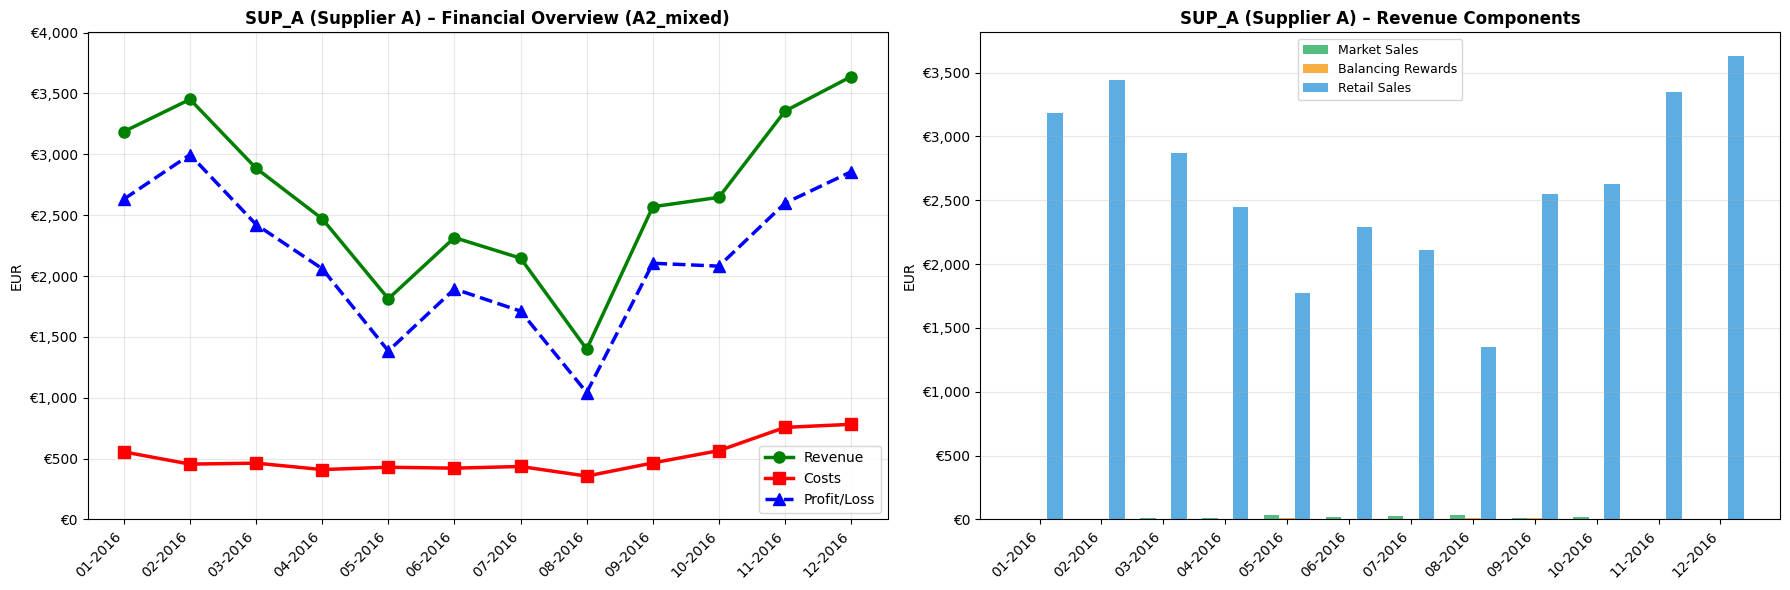

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

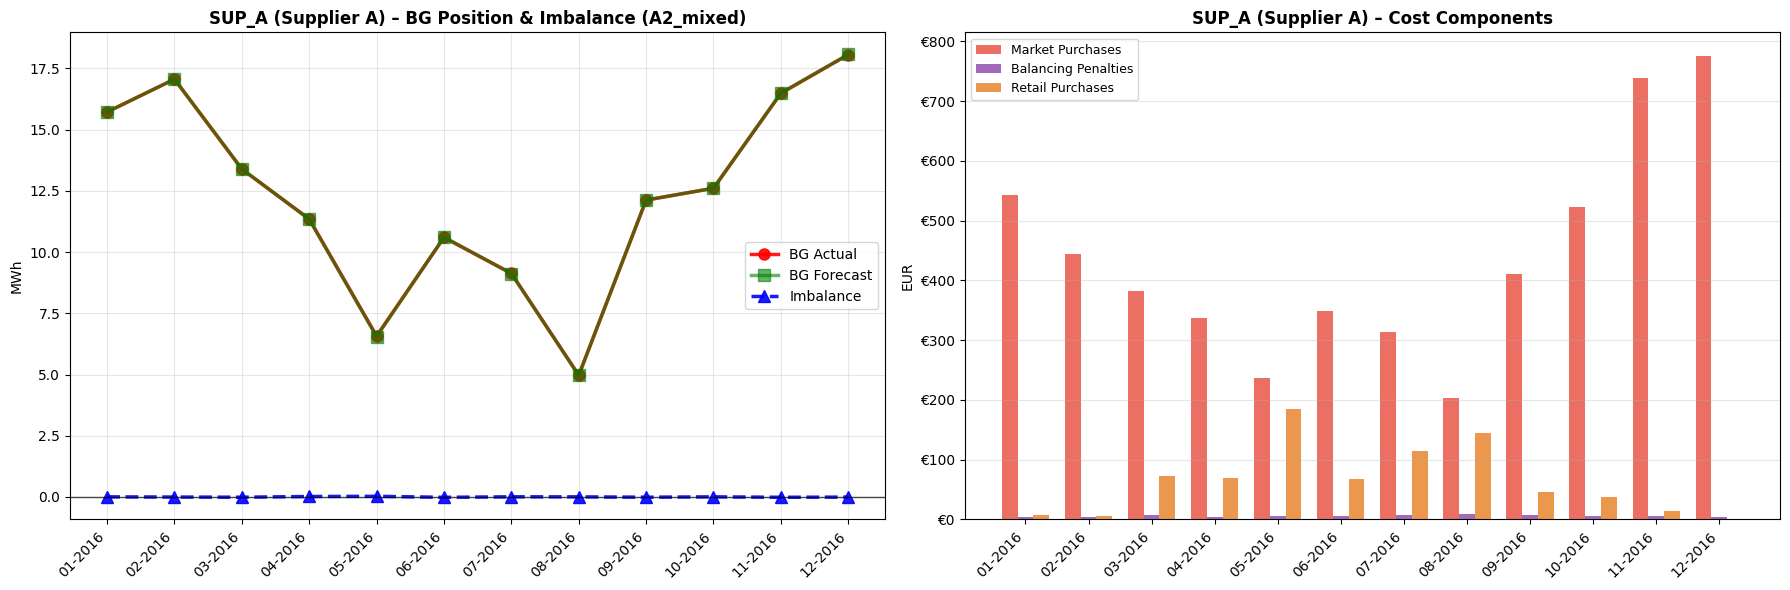

In [6]:
pipe.plot_imbalances()

## 7. REC Analysis & Monthly Data
Display total energy shared within the REC and monthly analysis DataFrame with all financial metrics.

In [7]:
# REC Analysis
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")
pipe.es_monthly_analysis_df

Total Shared Energy: 94.79 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,17.532878,0.074406,602.281473,1.797368,-1.715450,0.024128,29.579375,...,3.059716,2.439240,4.131813,3179.845359,3186.416411,543.221850,3.759606,8.011995,554.993451,2631.422960
1,02-2016,SUP_A,BG_A,19.107729,0.065242,494.289117,1.000277,-1.958210,0.018489,22.463459,...,5.285122,1.288584,4.491525,3445.447829,3451.227937,443.587695,4.392938,6.597385,454.578019,2996.649918
2,03-2016,SUP_A,BG_A,16.039708,0.803732,430.267683,11.430321,-1.769806,0.066489,24.094009,...,8.535020,12.666183,5.287190,2867.425737,2885.379109,382.896448,7.306179,72.301376,462.504003,2422.875106
3,04-2016,SUP_A,BG_A,13.856790,0.740528,382.911009,13.180574,-1.689523,0.091747,25.257687,...,11.156758,14.870016,5.622943,2449.264660,2469.757619,336.375362,4.916169,68.588396,409.879928,2059.877691
4,05-2016,SUP_A,BG_A,10.088920,2.039926,272.346920,26.667326,-1.279075,0.222535,22.993579,...,11.782869,31.054428,8.983114,1773.056596,1813.094138,237.357643,6.359462,185.257366,428.974471,1384.119667
5,06-2016,SUP_A,BG_A,12.938537,0.718319,394.866299,13.262446,-1.509338,0.099243,27.651608,...,9.687867,15.582818,6.141136,2293.686704,2315.410658,348.456915,5.787373,67.151142,421.395431,1894.015227
6,07-2016,SUP_A,BG_A,12.010879,1.250522,358.242903,22.689101,-1.492098,0.143167,27.138380,...,11.549817,25.913868,7.214823,2113.569625,2146.698316,313.747924,7.233370,114.077485,435.058779,1711.639537
7,08-2016,SUP_A,BG_A,7.787415,1.567736,233.787697,32.690097,-1.046827,0.206594,27.268374,...,11.335763,37.888653,7.923552,1352.914007,1398.726213,202.513268,8.709591,145.109900,356.332759,1042.393454
8,09-2016,SUP_A,BG_A,14.312761,0.463877,462.929502,10.440456,-1.632672,0.084286,30.137590,...,9.453632,12.703429,7.519984,2548.748932,2568.972345,410.206575,7.952185,46.087879,464.246639,2104.725706
9,10-2016,SUP_A,BG_A,14.612840,0.380204,585.042861,12.835531,-1.552765,0.074982,36.908256,...,6.187062,15.439746,6.164883,2624.826152,2646.430781,522.318391,6.098839,37.050997,565.468227,2080.962554
